> 慢即是快。这个项目不仅仅是一组 Prompt，它是一套**将顶级软件工程实践（如 TDD、Code Review、系统化调试）“硬编码”为 AI Coding 行为规范的操作系统**。它通过 Cursor/Claude 的 Tool/Skill 机制，强制 Agent 克服大模型常见的幻觉、懒惰和讨好倾向，严格遵循经过验证的工程思维链路。（字里行间充斥着软件工程思想，ai 协作中的软件工程实践的集大成者，harness（约束和控制，驾驭） engineering；）

- skills 加载工作原理（以 codex 为例）
    - codex 的 system prompt injection
    - 如何读结构化（markdown）的 system prompt
        - online markdown + 沉浸式翻译
- 如何理解这里的 superpowers 的各个 skills
    - 时序图，流程图
- 如何 writing 好的 skills（什么是好的 skills）
    - 非常考验 expert 经验，抽象，总结（可复用），writing 能力
    - formal 逻辑性的描述
    - 以 kimi 的 ppt skills 为参考

- `./skills/writing-skills/render-graphs.js ./skills/brainstorming`

### codex 中 skills 的暴露与加载

```
role:system(base_instructions)
role:developer -> 权限与沙箱规则 注入
role:user -> AGENTS.md 展示 skills description
role:developer -> collaboration_mode 注入
turn
role:user -> 真实的用户请求
role:assistant
role:assistant  -> cat SKILL.md
...
role:assistant
turn
role:user -> 用户开启一轮新的 query
```

- prompt injection 的方式，在前期的某 user message (第三条) 中暴露 skills
    - ~/.codex/AGENTS.md
    - codebase 目录的 AGENTS.md

```
<INSTRUCTIONS>
## Skills
A skill is a set of local instructions to follow that is stored in a `SKILL.md` file. Below is the list of skills that can be used. Each entry includes a name, description, and file path so you can open the source for full instructions when using a specific skill.
### Available skills
...  # abs path
### How to use skills
...
- How to use a skill (progressive disclosure):
  1) After deciding to use a skill, open its `SKILL.md`. Read only enough to follow the workflow.
...

</INSTRUCTIONS>
```

- model 根据用户的具体 query，（基于暴露的 skills 的 short description）匹配最佳的 skill，
    - 通过调用工具的方式（`function_call`, name=exec_command, 参数 `{"cmd":"cat /home/xx/.codex/superpowers/skills/using-superpowers/SKILL.md"}`）
    - 然后得到 `function_call_output` 的工具输出的消息

### codex skills

- codex 安装：自然语言安装
    - https://github.com/obra/superpowers/blob/main/.codex/INSTALL.md
    - native skill discovery. Just clone and symlink.
        - `/skills` 中原生发现，且可以 able/disable
    - `~/.agents/skills/`
        - https://developers.openai.com/codex/skills/
    - update
        - `cd ~/.codex/superpowers && git pull`
- 目前是 14 个 skill
    - 每个 skill 通过 SKILL.md frontmatter 的 description 定义“何时触发”（通常都以 Use when... 开头）。
    - using-superpowers：作为总控 skill，`Use when starting any conversation ...`（收到任何任务时，首先被 using-superpowers 拦截，强制检查是否需要应用特定技能。）
    - SKILL.md
        - Iron Law（铁律）：设定不可逾越的红线（例如“没有失败的测试就不准写生产代码”）。
        - HARD-GATE: brainstorming skill
        - Red Flags（红旗警告）：列出 AI 常见的“走捷径”心理（如“这个太简单了不需要测试”、“我先随便改一下试试”），一旦触发必须立刻停止并重来。
        - Checklist & Flowcharts：通过具体的待办列表和决策流程图，强制 AI 一步一步执行，防止遗漏。(test-driven-development, Verification Checklist)
    - skill 之间有编排关系，常见链路是：brainstorming -> writing-plans -> (subagent-driven-development 或 executing-plans) -> finishing-a-development-branch。

### `using-superpowers`

- `skills/using-superpowers/SKILL.md`
    - xml tag
    - mermaid 代码逻辑（formal）语言

```
<EXTREMELY-IMPORTANT>
If you think there is even a 1% chance a skill might apply to what you are doing, you ABSOLUTELY MUST invoke the skill.

IF A SKILL APPLIES TO YOUR TASK, YOU DO NOT HAVE A CHOICE. YOU MUST USE IT.

This is not negotiable. This is not optional. You cannot rationalize your way out of this.
</EXTREMELY-IMPORTANT>

```

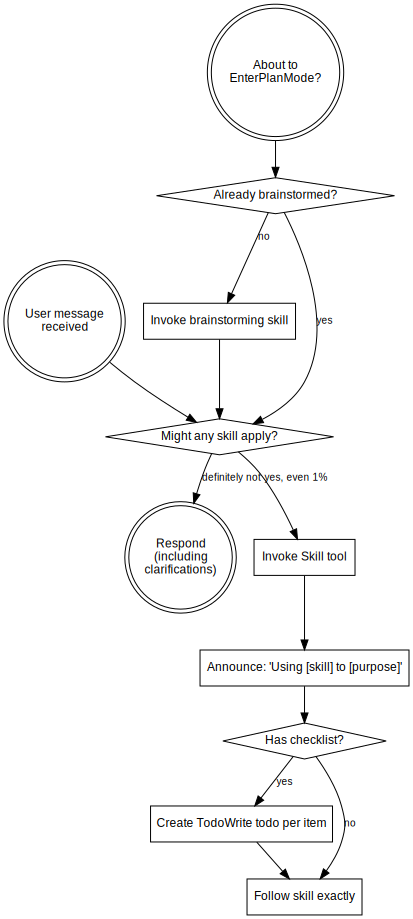

In [6]:
from graphviz import Source

dot_code = """
digraph skill_flow {
    // 【进阶设置】定义全局节点的默认字体和字号，提升整体质感
    node [fontname="Helvetica, Arial, sans-serif", fontsize=12];
    edge [fontname="Helvetica, Arial, sans-serif", fontsize=10];

    // ==========================================
    // 节点定义区：分离 ID 与 Label，优化形状比例
    // ==========================================
    
    "User message received" [
        shape=doublecircle, 
        label="User message\nreceived", 
        margin=0.02
    ];
    
    "About to EnterPlanMode?" [
        shape=doublecircle, 
        label="About to\nEnterPlanMode?", 
        margin=0.02
    ];
    
    "Respond (including clarifications)" [
        shape=doublecircle, 
        label="Respond\n(including\nclarifications)", 
        margin=0.02
    ];

    "Already brainstormed?" [shape=diamond];
    "Invoke brainstorming skill" [shape=box];
    "Might any skill apply?" [shape=diamond];
    "Invoke Skill tool" [shape=box];
    "Announce: 'Using [skill] to [purpose]'" [shape=box];
    "Has checklist?" [shape=diamond];
    "Create TodoWrite todo per item" [shape=box];
    "Follow skill exactly" [shape=box];

    // ==========================================
    // 边（关系）定义区：保持原有逻辑完全不变
    // ==========================================
    "About to EnterPlanMode?" -> "Already brainstormed?";
    "Already brainstormed?" -> "Invoke brainstorming skill" [label="no"];
    "Already brainstormed?" -> "Might any skill apply?" [label="yes"];
    "Invoke brainstorming skill" -> "Might any skill apply?";

    "User message received" -> "Might any skill apply?";
    "Might any skill apply?" -> "Invoke Skill tool" [label="yes, even 1%"];
    "Might any skill apply?" -> "Respond (including clarifications)" [label="definitely not"];
    "Invoke Skill tool" -> "Announce: 'Using [skill] to [purpose]'";
    "Announce: 'Using [skill] to [purpose]'" -> "Has checklist?";
    "Has checklist?" -> "Create TodoWrite todo per item" [label="yes"];
    "Has checklist?" -> "Follow skill exactly" [label="no"];
    "Create TodoWrite todo per item" -> "Follow skill exactly";
}
"""

s = Source(dot_code)
s

### brainstorming

- Ask clarifying questions — one at a time, understand purpose/constraints/success criteria（一次问一个澄清问题，理解目的、约束条件和成功标准）。
- 必须先探索上下文、逐个提问、给 2-3 方案、分段评审设计、写设计文档，再移交 writing-plans。
    - `docs/plans/YYYY-MM-DD-<topic>-design.md。`
    - brainstorming 先形成并保存 design doc，然后交给 writing-plans 形成真正的 implementation plan。

```
Do NOT invoke any implementation skill, write any code, scaffold any project, or take any implementation action until you have presented a design and the user has approved it. This applies to EVERY project regardless of perceived simplicity."
```

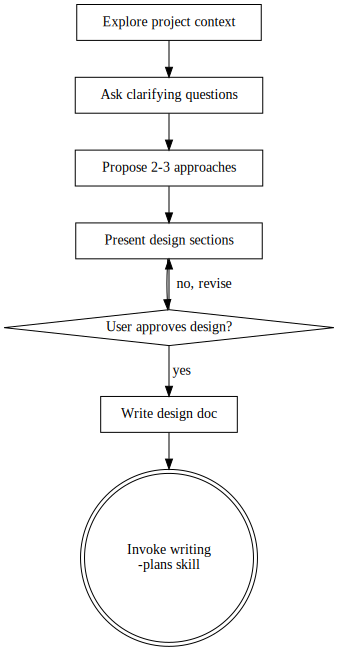

In [11]:
from graphviz import Source
dot_code = """
digraph brainstorming {
    "Explore project context" [shape=box];
    "Ask clarifying questions" [shape=box];
    "Propose 2-3 approaches" [shape=box];
    "Present design sections" [shape=box];
    "User approves design?" [shape=diamond];
    "Write design doc" [shape=box];
    "Invoke writing-plans skill" [shape=doublecircle, label="Invoke writing\n-plans skill"];

    "Explore project context" -> "Ask clarifying questions";
    "Ask clarifying questions" -> "Propose 2-3 approaches";
    "Propose 2-3 approaches" -> "Present design sections";
    "Present design sections" -> "User approves design?";
    "User approves design?" -> "Present design sections" [label="no, revise"];
    "User approves design?" -> "Write design doc" [label="yes"];
    "Write design doc" -> "Invoke writing-plans skill";
}
"""
Source(dot_code)

### writing-plans

- 把设计转成“零上下文工程师可执行”的细粒度计划。
    - DRY（Don’t Repeat Yourself）：避免重复代码/重复逻辑。
    - YAGNI（You Aren’t Gonna Need It）：不做“可能以后用得上”的功能或抽象。
    - TDD（Test-Driven Development）：测试驱动开发，先写测试再写实现。
    - 频繁提交：小步迭代，保持提交粒度小且清晰。
```
Write comprehensive implementation plans assuming the engineer has zero context for our codebase and questionable taste. Document everything they need to know... Give them the whole plan as bite-sized tasks. DRY. YAGNI. TDD. Frequent commits.
```

- Brainstorming 产出的是 架构设计文档 (Design Doc)，解决的是 “我们要建什么？为什么这么建？” (What & Why) 的问题。
    - 何时使用： 在任何创造性工作（新功能、新组件、修改现有行为）的最开始使用。此时，需求往往只有一个模糊的想法（例如：“我想加一个用户认证功能”）。
    - 核心目标：
        - 探索意图与约束：通过一问一答，弄清楚用户到底想要什么，性能要求是什么，有什么限制条件。
        - 方案选型：提出 2-3 种不同的技术方案（例如：用 JWT 还是 Session？），分析各自的 Trade-offs（权衡）。
        - 达成共识：向用户展示最终的架构设计，并获得用户的明确批准。
    - 产出物 (-design.md)：
        - 侧重于宏观架构、数据流向、组件交互、错误处理策略。
        - 里面几乎没有具体的代码实现，更多的是概念和决策。
        - 终点：一旦设计文档被用户批准并保存，brainstorming 技能的最后一步就是强制调用 writing-plans 技能。
- Writing-plans 产出的是 实施计划文档 (Implementation Plan)，解决的是 “我们具体怎么把代码写出来？” (How) 的问题。
    - 何时使用： 在需求和架构设计已经完全明确后（通常是紧接着 brainstorming 完成后），但在真正动手写代码之前使用。
    - 核心目标：
        - 任务拆解：将宏观的设计转化为极细粒度（2-5分钟能完成）的、可执行的步骤。
        - 消除执行时的上下文依赖：假设最终写代码的工程师（或另一个 AI Subagent）对项目一无所知。因此计划必须极其详尽。
    - 产出物 (-plan.md 或直接覆盖原文件)：
        - 侧重于微观执行。
        - 里面包含极其具体的细节：要创建哪个确切路径的文件（exact/path/to/file.py）、要修改哪几行、要写什么样的失败测试（TDD 的 RED 阶段代码）、要运行什么确切的命令行指令来验证。
        - 终点：计划写完后，不写代码，而是询问用户选择哪种执行模式（是当前会话用 Subagent 执行，还是开个新会话批量执行）。


### test-driven-development

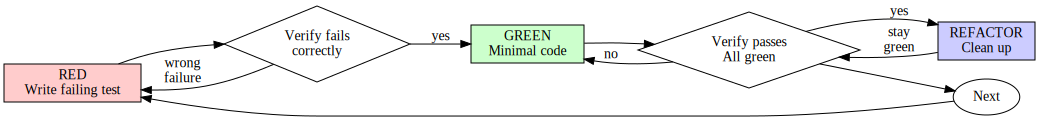

In [12]:
from graphviz import Source

dot_code = """
digraph tdd_cycle {
    rankdir=LR;
    red [label="RED\nWrite failing test", shape=box, style=filled, fillcolor="#ffcccc"];
    verify_red [label="Verify fails\ncorrectly", shape=diamond];
    green [label="GREEN\nMinimal code", shape=box, style=filled, fillcolor="#ccffcc"];
    verify_green [label="Verify passes\nAll green", shape=diamond];
    refactor [label="REFACTOR\nClean up", shape=box, style=filled, fillcolor="#ccccff"];
    next [label="Next", shape=ellipse];

    red -> verify_red;
    verify_red -> green [label="yes"];
    verify_red -> red [label="wrong\nfailure"];
    green -> verify_green;
    verify_green -> refactor [label="yes"];
    verify_green -> green [label="no"];
    refactor -> verify_green [label="stay\ngreen"];
    verify_green -> next;
    next -> red;
}
"""

s = Source(dot_code)
s

- 严格执行红-绿-重构（Red-Green-Refactor）的测试驱动开发纪律。严禁在没有看到测试失败的情况下编写生产代码。
    - TDD 的三个标准步骤。红：写一个会失败的测试；绿：写最少量的代码让它通过；重构：在保持测试绿色的前提下优化代码结构。

```
"NO PRODUCTION CODE WITHOUT A FAILING TEST FIRST."
"Write code before the test? Delete it. Start over. No exceptions: Don't keep it as 'reference', Don't 'adapt' it while writing tests... Delete means delete."
```

- 必须亲眼看着测试失败 (Verify RED)：写完测试后必须运行并看到预期的报错。如果测试直接通过了，说明它测的是错的，或者测的是已经存在的行为（这在 test-driven-development 中被定为铁律）。
- 事后测试证明不了任何事 (Tests-after prove nothing)：写完代码再补测试，往往只会测试“代码现在的行为”，而不是“代码应该的行为”，这种行为被视为技术债务。
- 主张前必须要有证据 (Evidence before assertions)：在宣布“已完成”或“测试通过”前，必须真实运行命令行工具并检查 Exit Code / 实际输出。禁止使用“我觉得应该修好了”、“Linter过了等于构建成功”等主观推断（来自 verification-before-completion）。

### executing-plans vs. subagent-driven-development

- subagent-driven-development
    - 计划中的任务彼此独立、低耦合，希望系统自动跑完。
    - 为每个任务派发新 Subagent，完成后进行双重机器审查（Spec + Quality）。
- executing-plans 是一种宏观层面的管理模式，但它强调的是批处理与人类审查（Human-in-the-loop，`review checkpoints`，任务极其复杂、高风险，需要人类步步把关）。
    - 当你有一份详细的计划，但这个任务非常复杂、牵一发而动全身、或者容易跑偏时。
    - 分批执行（Batch execution）。每做完一小批必须停下，等待人类反馈再继续。

### `using-git-worktrees` / `dispatching-parallel-agents` / `subagent-driven-development`

- using-git-worktrees -> subagent-driven-development
    - subagent-driven-development 在单个计划执行里强调每个任务按 Implementer -> Spec Reviewer -> Code Quality Reviewer 的顺序门禁
- dispatching-parallel-agents 适用于“多个独立问题域并发调查/修复”
- subagent / parallel
    - Subagent-Driven（当前会话）：coding agent 在这个会话里按计划逐任务实现、跑测试、逐步回看结果。
    - Parallel Session（单独会话）：用户开一个新会话，按实现计划用 executing-plans 流程批量推进。

### systematic-debugging

- 遇到 Bug 或测试失败时使用。禁止 AI 盲目猜测和“试错式”修复（Symptom fixes），强制要求分为四步：寻找根本原因 -> 分析模式 -> 提出假设 -> 最小化实现与验证。
    - 任何 bug/失败先做根因调查，禁止拍脑袋修。
    - 四阶段固定顺序（根因调查 -> 模式分析 -> 假设验证 -> 实施）；3 次以上失败要升级到架构质疑。
```
> "NO FIXES WITHOUT ROOT CAUSE INVESTIGATION FIRST."
> "Random fixes waste time and create new bugs. Quick patches mask underlying issues. Core principle: ALWAYS find root cause before attempting fixes. Symptom fixes are failure."
```

### verification-before-completion

- 终结 AI 喜欢“假装完成”或“过度自信”的坏习惯。在宣布任务完成、测试通过或准备提交前，必须真实地运行验证命令，并根据实际输出（Evidence）来说话。

```
> "NO COMPLETION CLAIMS WITHOUT FRESH VERIFICATION EVIDENCE."
> "If you haven't run the verification command in this message, you cannot claim it passes. Claiming work is complete without verification is dishonesty, not efficiency."
> Skip any step = lying, not verifying
```

### requesting-code-review / receiving-code-review 

- Shift-Left Testing/Review (测试/审查左移): 软件工程质量保证的重要理念。指在软件开发生命周期的早期阶段（左侧）就引入测试和审查，而不是等到开发后期（右侧）。这样可以以最低的成本发现和修复缺陷。
    - Review early, review often
        - 不仅在合并主分支（Merge to main）前需要审查，在每一个极细粒度的子任务（Task）完成后，都必须强制触发审查。
        - “审查左移”的体现。通过在每个小步骤后进行审查，可以确保当前步骤的输出是可靠的，防止错误的设计思路（Cascading Issues）污染下一个任务。
- 优秀的 Code Review 必须基于清晰的上下文。如果没有需求作为对照，Reviewer 只能审查代码风格，而无法判断代码是否真正解决了业务问题。
    - 呼叫 code-reviewer 子代理时，必须提供精确的上下文，包括：
        - {WHAT_WAS_IMPLEMENTED}: 刚刚实现了什么。
        - {PLAN_OR_REQUIREMENTS}: 原始的需求或计划是什么（用于核对 Spec Compliance）。
        - {BASE_SHA} & {HEAD_SHA}: 精确的 Git 提交范围。
```bash
BASE_SHA=$(git rev-parse HEAD~1)  # or origin/main
HEAD_SHA=$(git rev-parse HEAD)
```
- The 5-Dimensional Review Checklist（`code-reviewer.md`）
    - Code Quality (代码质量): 关注点分离（Separation of concerns）、错误处理、DRY 原则、边界情况。
    - Architecture (架构): 设计决策是否合理、可扩展性、性能影响、安全隐患。
    - Testing (测试): 测试是否测了真实的逻辑（而不是仅仅测了 Mock）、边界覆盖率、集成测试。
    - Requirements (需求合规): 是否满足了计划的所有要求、没有范围蔓延（No scope creep）。
    - Production Readiness (生产就绪度): 数据库迁移策略、向后兼容性（Backward compatibility）、文档完整性。
- 行为红线 (Critical Rules)：模板最后给 Reviewer 设定了“Do & Don't”：
    - DON'T: Say "looks good" without checking (严禁不看代码就说“看起来不错”)。
    - DON'T: Mark nitpicks as Critical (严禁把吹毛求疵标为致命错误)。
    - DON'T: Avoid giving a clear verdict (严禁含糊其辞，必须给出最终结论)。
----
- Code Review 的本质：是一场基于客观代码的技术评估，而不是一场为了讨好 Reviewer 的社交表演。
    - Technical Rigor (技术严谨性): 决策必须基于事实、测试结果、系统架构现状，而不是基于直觉、权威或社交压力。
    - Performative Agreement (表演性同意/盲从): 协作反模式。开发者（或 AI）为了显得“配合”或“态度好”，在没有验证技术可行性的情况下，盲目同意并执行 Reviewer 的建议。
    - YAGNI (You Aren't Gonna Need It): 极限编程原则。如果 Reviewer 建议添加一个“看起来很专业”但当前系统根本没有调用的功能，必须用 YAGNI 原则进行反驳。
    - Backward Compatibility (向后兼容性/历史包袱): 现有代码库中为了兼容旧版本或特定环境而存在的“看似不合理”的代码。
- 验证先于执行 (Verify before implementing)
    - 做法：收到反馈后，严禁立刻说 "You're absolutely right! Let me fix it..."。第一步必须是：去代码库中验证（Verify against codebase reality）。
    - 实践意义：Reviewer（无论是人类还是外部工具）往往缺乏全局上下文。他们可能建议删除一段“看起来无用”的代码，但这部分代码可能是为了处理某个特定的向后兼容性（Backward Compatibility）问题。盲目听从会导致系统崩溃。
- 有理有据的技术反驳 (Reasoned Pushback)
    - 做法：如果发现 Reviewer 的建议是错误的（例如：破坏了现有功能、违反了 YAGNI、不符合当前技术栈），必须使用技术推理进行反驳。
    - 实践意义：优秀的工程师不仅要会写代码，还要能捍卫系统的架构完整性。反驳不是为了争吵，而是为了保护代码库。例如，如果 Reviewer 要求加一个复杂的指标导出功能，AI 应该先 grep 代码库，发现没用到，然后回复："This endpoint isn't called. Remove it (YAGNI)?"
- 消除模糊性 (Handling Unclear Feedback)
    - 做法：如果 Reviewer 提了 6 点意见，其中 2 点表述不清。严禁先做懂的 4 点，把不懂的 2 点留到最后。必须立刻停止，先询问清楚所有细节。
实践意义：软件模块之间往往是高度耦合的。部分理解（Partial understanding）会导致错误的实现方向，返工成本极高。
- 行动胜于雄辩 (Actions Speak Louder Than Words)
    - 做法：当 Reviewer 的意见是正确的时候，严禁使用任何感激或赞美的废话（如 "Great point!", "Thanks for catching that!"）。正确的做法是：直接修复它，并简短陈述事实（"Fixed. [Brief description]"）。
    - 实践意义：在高效的工程文化中，代码本身就是最好的回应。消除情绪化的社交废话，可以极大提高沟通的信噪比（Signal-to-Noise Ratio）。

### Code Review 架构设计模式与代码风格

- SOLID 与关注点分离：在 `requesting-code-review`（代码审查）的 Agent 设定中，明确要求 Reviewer 必须检查代码是否遵循 SOLID 原则，以及是否有清晰的关注点分离 (Clean separation of concerns)。
    - SOLID 原则 (面向对象设计的五大基石)
        - S - 单一职责原则 (Single Responsibility Principle, SRP)
        - O - 开闭原则 (Open/Closed Principle, OCP)
            - 对扩展开放，对修改关闭。
        - L - 里氏替换原则 (Liskov Substitution Principle, LSP)
        - I - 接口隔离原则 (Interface Segregation Principle, ISP)
        - D - 依赖倒置原则 (Dependency Inversion Principle, DIP)
    - 关注点分离是一种宏观的架构哲学，主张将软件划分为具有不同职责的独立模块，使得每个模块只解决一个特定的“关注点”（如业务逻辑、数据访问、用户界面）。
    - Code Review 检查清单：在 code-reviewer.md 中，代码风格和质量被分为几个维度进行强制审查：
        - 是否进行了适当的错误处理 (Proper error handling)？
        - 是否保证了类型安全 (Type safety)？
        - 边缘情况 (Edge cases) 是否被处理？
        - 是否包含“魔法数字 (Magic numbers)”？（在审查示例中，将代码里硬编码的 100 标记为需要修复的 Minor Issue）。
        - 消除防御性编程的冗余：在编写代码和脚本时，要求“解决问题，而不是把问题抛出 (Solve, don't punt)”，要求错误处理必须是明确且有帮助的，而不是简单地吞掉异常。
- 代码复用
    - 在 writing-plans（编写实施计划）和代码审查中，DRY (Don't Repeat Yourself) 和 YAGNI (You Aren't Gonna Need It) 被反复强调。
    - 既要复用代码（DRY），又要坚决杜绝过度设计和过度抽象（YAGNI，即“你不需要它就别写”）。
    - 在 writing-skills 和 anthropic-best-practices 中，强调将解决问题的过程提炼为可复用的模式 (Reusable patterns)，而不是一次性的脚本或叙述，这本身就是对知识和逻辑抽象的极高要求。